In [ ]:
# ==============================
# 1. INSTALL & IMPORTS
# ==============================
!pip install -q opendatasets

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, Activation
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight






In [ ]:
# ==============================
# 2. REPRODUCIBILITY
# ==============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ==============================
# 3. DOWNLOAD DATASET
# ==============================
import opendatasets as od
od.download("https://www.kaggle.com/datasets/ebisagetachew/dragamen")

# ✅ FIXED PATH
dataset_dir = "dragamen/emotion_dataset"
train_dir = os.path.join(dataset_dir, "train")
test_dir  = os.path.join(dataset_dir, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: amen
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ebisagetachew/dragamen


100%|██████████| 565M/565M [00:16<00:00, 34.9MB/s]



Train path: dragamen/emotion_dataset/train
Test path: dragamen/emotion_dataset/test


In [ ]:
# ==============================
# 4. PARAMETERS
# ==============================
IMAGE_SIZE = (48, 48)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 7
COLOR_MODE = "grayscale"




In [ ]:
dataset_dir = "dragamen/emotion_dataset"

train_dir = os.path.join(dataset_dir, "train")
test_dir  = os.path.join(dataset_dir, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)

Train path: dragamen/emotion_dataset/train
Test path: dragamen/emotion_dataset/test


In [ ]:
import os

print(os.listdir("dragamen"))

['test', 'train']


In [ ]:
train_dir = "dragamen/train"
test_dir  = "dragamen/test"

In [ ]:
# ==============================
# 5. DATA GENERATORS (IMPROVED)
# ==============================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    color_mode=COLOR_MODE,
    subset='training',
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    color_mode=COLOR_MODE,
    subset='validation',
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    color_mode=COLOR_MODE,
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print("Classes:", class_names)




Found 35840 images belonging to 7 classes.
Found 8960 images belonging to 7 classes.
Found 11200 images belonging to 7 classes.
Classes: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
# ==============================
# 6. CLASS WEIGHTS (IMPORTANT)
# ==============================
classes = np.unique(train_gen.classes)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0)}


In [ ]:
# ==============================
# 7. BEST CNN MODEL
# ==============================
inputs = Input(shape=(48,48,1))

# Block 1
x = Conv2D(32, (3,3), padding='same')(inputs)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(32, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D()(x)
x = Dropout(0.25)(x)

# Block 2
x = Conv2D(64, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(64, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D()(x)
x = Dropout(0.25)(x)

# Block 3
x = Conv2D(128, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(128, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D()(x)
x = Dropout(0.3)(x)

# Block 4
x = Conv2D(256, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D()(x)
x = Dropout(0.4)(x)

# Dense
x = Flatten()(x)
x = Dense(256)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,177,319 (4.49 MB)

 Trainable params: 1,175,399 (4.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
# ==============================
# 8. CALLBACKS
# ==============================
os.makedirs("models", exist_ok=True)
model_path = "models/best_emotion_cnn.keras"

callbacks = [
    ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, verbose=1),

    ReduceLROnPlateau(
        monitor='val_loss',
        patience=2,
        factor=0.3,
        min_lr=1e-6,
        verbose=1
    ),

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]


In [ ]:
# ==============================
# 9. TRAIN
# ==============================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/30
1119/1120 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1672 - loss: 2.2327
Epoch 1: val_accuracy improved from None to 0.22154, saving model to models/best_emotion_cnn.keras

Epoch 1: finished saving model to models/best_emotion_cnn.keras
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 85s 60ms/step - accuracy: 0.1858 - loss: 2.1080 - val_accuracy: 0.2215 - val_loss: 1.9007 - learning_rate: 5.0000e-04
Epoch 2/30
1119/1120 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2335 - loss: 1.9193
Epoch 2: val_accuracy improved from 0.22154 to 0.26283, saving model to models/best_emotion_cnn.keras

Epoch 2: finished saving model to models/best_emotion_cnn.keras
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 64s 58ms/step - accuracy: 0.2490 - loss: 1.8810 - val_accuracy: 0.2628 - val_loss: 1.8475 - learning_rate: 5.0000e-04
Epoch 3/30
1119/1120 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2850 - loss: 1.7964
Epoch 3: val_accuracy did not improve from 0.26283
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 65s 58ms/step - accura


Test Accuracy: 64.10%
350/350 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step
F1-score: 0.6301

Classification Report:
              precision    recall  f1-score   support

       anger       0.58      0.57      0.58      1600
     disgust       0.75      0.79      0.77      1600
        fear       0.59      0.27      0.37      1600
       happy       0.84      0.81      0.82      1600
     neutral       0.51      0.74      0.61      1600
         sad       0.51      0.49      0.50      1600
    surprise       0.72      0.81      0.76      1600

    accuracy                           0.64     11200
   macro avg       0.64      0.64      0.63     11200
weighted avg       0.64      0.64      0.63     11200



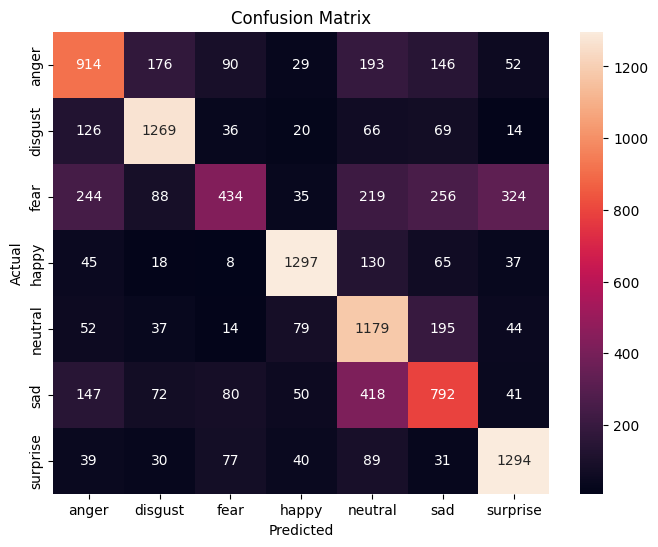

In [ ]:
# ==============================
# 10. EVALUATION
# ==============================
model = keras.models.load_model(model_path)

loss, acc = model.evaluate(test_gen, verbose=0)
print(f"\nTest Accuracy: {acc*100:.2f}%")

# Predictions
y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

# Metrics
f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()